In [64]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


In [66]:
#data_path = os.path.abspath('../data/time_series_data.csv') 
df = pd.read_csv("../data/time_series_data.csv")
df.head()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
0,1,197,66,266,113,2,1,18
1,2,153,44,264,74,1,2,21
2,3,128,55,317,116,0,1,19
3,4,133,57,390,70,0,2,17
4,5,120,47,440,141,1,1,18


In [68]:
df.tail()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
95,96,174,226,975,94,0,1,2
96,97,158,201,1141,91,0,2,3
97,98,145,217,881,46,4,1,3
98,99,161,249,741,70,0,1,7
99,100,160,331,854,75,0,1,5


In [70]:
df.describe()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
count,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,148.370000,153.440000,631.5800,80.120000,0.550000,1.470000,13.020000
std,29.011492,18.061989,68.164288,202.8871,36.780891,1.225775,0.501614,5.915192
min,1.000000,107.000000,42.000000,203.0000,11.000000,0.000000,1.000000,2.000000
25%,25.750000,134.000000,95.500000,491.7500,55.750000,0.000000,1.000000,9.000000
50%,50.500000,151.000000,155.500000,611.0000,70.000000,0.000000,1.000000,13.000000
75%,75.250000,160.000000,200.250000,770.5000,100.250000,0.000000,2.000000,17.000000
max,100.000000,197.000000,331.000000,1141.0000,194.000000,5.000000,2.000000,26.000000


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   t            100 non-null    int64
 1   ProductP1    100 non-null    int64
 2   ProductP2    100 non-null    int64
 3   ProductP3    100 non-null    int64
 4   ProductP4    100 non-null    int64
 5   ProductP5    100 non-null    int64
 6   price        100 non-null    int64
 7   temperature  100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


### Weekly data preparation

In [75]:
import pandas as pd
from datetime import timedelta

df2 = df.copy()

# Last date
last_date = pd.to_datetime('2019-08-30')

# Calculate the starting date
start_date = last_date - timedelta(weeks=99)

# Generate a date range
date_range = pd.date_range(start=start_date, periods=100, freq='W')

# Map the 't' column to the date range
df2['date'] = df2['t'].apply(lambda x: date_range[x-1])

# Drop the 't' column
df2.drop(columns=['t'], inplace=True)


df2.head()

,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature,date
0,197,66,266,113,2,1,18,2017-10-08
1,153,44,264,74,1,2,21,2017-10-15
2,128,55,317,116,0,1,19,2017-10-22
3,133,57,390,70,0,2,17,2017-10-29
4,120,47,440,141,1,1,18,2017-11-05


In [77]:
# Select the necessary columns
weekly_data = df2[["date", "ProductP1", "ProductP2", "ProductP5"]]
weekly_data.head()

,date,ProductP1,ProductP2,ProductP5
0,2017-10-08,197,66,2
1,2017-10-15,153,44,1
2,2017-10-22,128,55,0
3,2017-10-29,133,57,0
4,2017-11-05,120,47,1


### Daily data preparation

In [80]:
df3 = df.copy()

# Last date
last_date = pd.to_datetime('2019-11-24')

# Calculate the starting date
start_date = last_date - timedelta(days=99)

# Generate a date range
date_range = pd.date_range(start=start_date, periods=100, freq='D')

# Map the 't' column to the date range
df3['date'] = df3['t'].apply(lambda x: date_range[x-1])

# Drop the original 't' column
df3.drop(columns=['t'], inplace=True)

df3.head()

,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature,date
0,197,66,266,113,2,1,18,2019-08-17
1,153,44,264,74,1,2,21,2019-08-18
2,128,55,317,116,0,1,19,2019-08-19
3,133,57,390,70,0,2,17,2019-08-20
4,120,47,440,141,1,1,18,2019-08-21


In [82]:
# Select the necessary columns
daily_data = df3[["date", "ProductP3", "ProductP4", "price", "temperature"]]
daily_data.head()

,date,ProductP3,ProductP4,price,temperature
0,2019-08-17,266,113,1,18
1,2019-08-18,264,74,2,21
2,2019-08-19,317,116,1,19
3,2019-08-20,390,70,2,17
4,2019-08-21,440,141,1,18


In [84]:
weekly_data.describe().T

,count,mean,min,25%,50%,75%,max,std
date,100,2018-09-19 12:00:00,2017-10-08 00:00:00,2018-03-30 06:00:00,2018-09-19 12:00:00,2019-03-11 18:00:00,2019-09-01 00:00:00,NaN
ProductP1,100.0,148.37,107.0,134.0,151.0,160.0,197.0,18.061989
ProductP2,100.0,153.44,42.0,95.5,155.5,200.25,331.0,68.164288
ProductP5,100.0,0.55,0.0,0.0,0.0,0.0,5.0,1.225775


### Weekly data clustering

In [87]:
# Standardize the data
scaler = StandardScaler()
wd_scaled = scaler.fit_transform(weekly_data[["ProductP1", "ProductP2", "ProductP5"]])

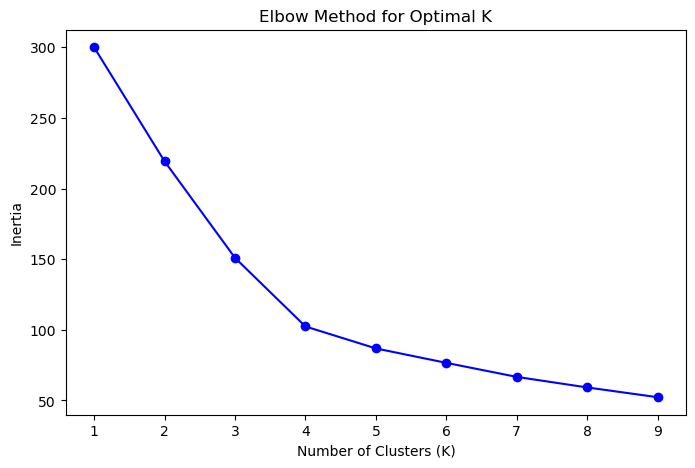

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(wd_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [91]:
# Apply PCA with all components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(wd_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

PC1: 0.3488 (Cumulative: 0.3488)
PC2: 0.3333 (Cumulative: 0.6822)
PC3: 0.3178 (Cumulative: 1.0000)


In [93]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 4

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
weekly_data["Cluster"] = kmeans.fit_predict(wd_scaled)

ERROR! Session/line number was not unique in database. History logging moved to new session 15


/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_71352/1826665429.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weekly_data["Cluster"] = kmeans.fit_predict(wd_scaled)


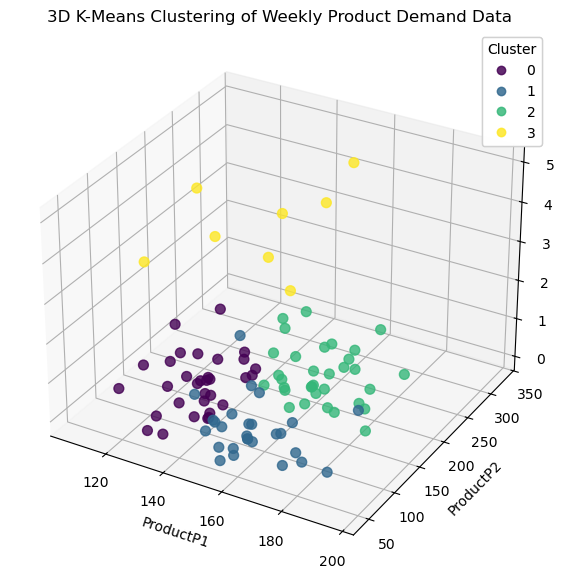

In [95]:
# Apply PCA with n_components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(wd_scaled)

# 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(weekly_data["ProductP1"], weekly_data["ProductP2"], weekly_data["ProductP5"], 
                      c=weekly_data["Cluster"], cmap="viridis", s=50, alpha=0.8)

ax.set_xlabel("ProductP1")
ax.set_ylabel("ProductP2")
ax.set_zlabel("ProductP5")
ax.set_title("3D K-Means Clustering of Weekly Product Demand Data")

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

In [99]:
# Get PCA Loadings (Feature contributions to PCs)
pca_loadings_full = pd.DataFrame(pca.components_.T, 
                                 columns=[f"PC{i+1}" for i in range(4)],
                                 index=["ProductP3", "ProductP4", "price", "temperature"])

# Display the PCA Loadings
tools.display_dataframe_to_user(name="PCA Loadings (Product3, Product4, Temperature, Price)", dataframe=pca_loadings_full)

ValueError: Shape of passed values is (3, 3), indices imply (4, 4)

In [ ]:
# Pair plot
weekly_data["Cluster"] = weekly_data["Cluster"].astype(str)
sns.pairplot(weekly_data, hue="Cluster", palette="viridis", diag_kind="kde")

### Daily data clustering

In [ ]:
daily_data.describe().T

In [ ]:
# Standardize the data
dd_scaled = scaler.fit_transform(daily_data[["ProductP3", "ProductP4", "price", "temperature"]])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dd_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [ ]:
# Apply PCA with all components
pca = PCA(n_components=4)
X_pca = pca.fit_transform(dd_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

In [ ]:
# Choose the optimal number of clusters
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)

# Visualizing cluster distribution using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(dd_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=daily_data["Cluster"], palette="viridis", s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Product Demand Data")
plt.legend(title="Cluster")
plt.show()

In [ ]:
daily_data.head()

In [ ]:
daily_data[daily_data["Cluster"] == 0].describe().T

In [ ]:
daily_data[daily_data["Cluster"] == 1].describe().T

In [ ]:
daily_data[daily_data["Cluster"] == 2].describe().T

In [ ]:
# Apply PCA with n_components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(dd_scaled)

# 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                      c=daily_data["Cluster"], cmap="viridis", s=50, alpha=0.8)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D K-Means Clustering of Daily Product Demand Data")

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

In [ ]:
# Choose the optimal number of clusters
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)

In [ ]:
# Pair plot
daily_data["Cluster"] = daily_data["Cluster"].astype(str)
sns.pairplot(daily_data, hue="Cluster", palette="viridis", diag_kind="kde")

### EDA

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(weekly_data["date"], weekly_data["ProductP1"], label="ProductP1")
plt.plot(weekly_data["date"], weekly_data["ProductP2"], label="ProductP2")
plt.plot(weekly_data["date"], weekly_data["ProductP5"], label="ProductP5")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.title("Weekly Product Demand Over Time")
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(daily_data["date"], daily_data["ProductP3"], label="ProductP3")
plt.plot(daily_data["date"], daily_data["ProductP4"], label="ProductP4")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.title("Daily Product Demand Over Time")
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(daily_data["date"], daily_data["temperature"], label="temperature")
plt.xlabel("Time")
plt.ylabel("Celcieus")
plt.legend()
plt.title("Temperature Over Time")
plt.show()

In [ ]:
# Compute correlation matrix for weekly products
corr_matrix = weekly_data[["ProductP1", "ProductP2", "ProductP5"]].corr()

# correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Weekly Products & Explanatory Variables)")
plt.show()

In [ ]:
# Compute correlation matrix for daily products
corr_matrix = daily_data[["ProductP3", "ProductP4", "price", "temperature"]].corr()

# correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Daily Products & Explanatory Variables)")
plt.show()

In [ ]:
#Autocorelation weekly
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(weekly_data["ProductP1"], lags=70)  # Adjust lags based on your data length
plt.title("Autocorrelation Matrix ProductP1")
plt.show()

In [ ]:
plot_acf(weekly_data["ProductP2"], lags=70)  # Adjust lags based on your data length
plt.title("Autocorrelation Matrix ProductP2")
plt.show()

In [ ]:
plot_acf(weekly_data["ProductP5"], lags=70)  # Adjust lags based on your data length
plt.title("Autocorrelation Matrix ProductP5")
plt.show()

In [ ]:
#Autocorelation daily
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(daily_data["ProductP3"], lags=30)  # Adjust lags based on your data length
plt.title("Autocorrelation Matrix ProductP3")
plt.show()

In [ ]:
plot_acf(daily_data["ProductP4"], lags=30)  # Adjust lags based on your data length
plt.title("Autocorrelation Matrix ProductP4")
plt.show()

### Stationary testing

In [ ]:
from statsmodels.tsa.stattools import adfuller

# check stationarity
def check_stationarity(series):
    result = adfuller(series)
    return {"Test Statistic": result[0], "p-value": result[1], "Stationary": result[1] < 0.05}

# Apply ADF test
stationarity_results = {col: check_stationarity(df[col]) for col in df.columns}
pd.DataFrame(stationarity_results).T

### Seasonal Pattern Identification

In [ ]:
plt.figure(figsize=(8, 6))
cols = ["ProductP1","ProductP2","ProductP5"]

for idx, i in enumerate(cols):
    plt.subplot(3, 1, idx+1)
    plt.plot(weekly_data["date"], df[i], label=i)
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.title(f"{i} Over Time")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
cols = ["ProductP3","ProductP4"]

for idx, i in enumerate(cols):
    plt.subplot(3, 1, idx+1)
    plt.plot(daily_data["date"], df[i], label=i)
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.title(f"{i} Over Time")
plt.tight_layout()
plt.show()

### Variable Decomposition

In [ ]:
# Decompose weekly product
p1_decomp = seasonal_decompose(weekly_data["ProductP1"], period=4, model="additive")
p2_decomp = seasonal_decompose(weekly_data["ProductP2"], period=4, model="multiplicative")
p5_decomp = seasonal_decompose(weekly_data["ProductP5"], period=4, model="additive")

# Decompose daily product
p3_decomp = seasonal_decompose(daily_data["ProductP3"], period=30, model="multiplicative")
p4_decomp = seasonal_decompose(daily_data["ProductP4"], period=30, model="additive")

In [ ]:
# Plot decompositions
p1_decomp.plot()
plt.show()

In [ ]:
# Plot decompositions
p2_decomp.plot()
plt.show()

In [ ]:
# Plot decompositions
p5_decomp.plot()
plt.show()

In [ ]:
# Plot decompositions
p3_decomp.plot()
plt.show()

In [ ]:
# Plot decompositions
p4_decomp.plot()
plt.show()

### Cointegration Testing

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Run the Granger causality test
max_lag = 5  # Adjust as needed
gc_test = grangercausalitytests(df[['ProductP3', 'temperature']], maxlag=max_lag, verbose=False)

# Extract p-values for each lag
p_values = {lag: round(gc_test[lag][0]['ssr_chi2test'][1], 4) for lag in range(1, max_lag + 1)}

# Display p-values
print("Granger Causality p-values:", p_values)

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Select only the relevant columns
data = weekly_data[["ProductP2", "ProductP5"]]

# Perform Johansen test
johansen_test = coint_johansen(data, det_order=0, k_ar_diff=1)

# Trace statistic and critical values
trace_stat = johansen_test.lr1
critical_values = johansen_test.cvt

# Display results
for i in range(len(trace_stat)):
    print(f"Rank {i}: Trace Statistic = {trace_stat[i]:.4f}, Critical Values = {critical_values[i]}")
    
    if trace_stat[i] > critical_values[i][1]:  # Compare with 5% critical value
        print(" Evidence of cointegration at 5% significance level.")
    else:
        print(" No strong evidence of cointegration.")

### Model Development

### Product 1

In [ ]:
# Rename columns
df_prophet = weekly_data.rename(columns={"date": "ds", "ProductP1": "y"})

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [ ]:
df_prophet.head()

In [ ]:
from prophet import Prophet

# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe
future = model.make_future_dataframe(periods=30, freq='W')

# Forecast
forecast = model.predict(future)

In [ ]:
future.tail()

In [ ]:
import matplotlib.pyplot as plt

# Plot forecast
fig = model.plot(forecast)
plt.show()

### Hyper Parameter tuning product 01

In [ ]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [0.1, 1.0, 10.0, 20.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

In [ ]:
import matplotlib.pyplot as plt

# Predict using the best model
future = best_model.make_future_dataframe(periods=10, freq='W')

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="70 days",   
                         period="14 days",    
                         initial="480 days")  

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

### Product 2

In [ ]:
# Rename columns for FBProphet
df_prophet = weekly_data.rename(columns={"date": "ds", "ProductP2": "y"})

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [ ]:
df_prophet.head()

In [ ]:
from prophet import Prophet

# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 weeks)
future = model.make_future_dataframe(periods=10, freq='W')
# future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

In [ ]:
import matplotlib.pyplot as plt

# Plot forecast
fig = model.plot(forecast)
plt.show()

### Hyper Parameter tuning product 02

In [ ]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.001, 0.01, 0.02, 0.03, 0.05],
    "seasonality_prior_scale": [0.05,0.06,0.08,0.1, 0.15, 0.2],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].mean()  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

In [ ]:
import matplotlib.pyplot as plt

# Predict using the best model
future = best_model.make_future_dataframe(periods=10, freq='W')
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="70 days",   
                         period="14 days",    
                         initial="480 days")  

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

### Product 3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM, select_order
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import itertools

In [ ]:
# Keep only necessary columns
df_vecm = daily_data[["date", "ProductP3", "ProductP4", "temperature", "price"]]
df_vecm.set_index('date', inplace=True)

In [ ]:
df_vecm.head()

In [ ]:
# Perform Johansen cointegration test
result = coint_johansen(df_vecm[['ProductP3', 'ProductP4']], det_order=0, k_ar_diff=1)

# Print test results
print("Johansen Cointegration Test Results:")
print("Test Statistics:", result.lr1)
print("Critical Values (90%, 95%, 99%):", result.cvt)

# Interpret the results
print("\nInterpretation and Conclusion:")

# Compare test statistics to critical values
for i, test_stat in enumerate(result.lr1):
    cv_90, cv_95, cv_99 = result.cvt[i]
    print(f"\nFor hypothesis {i}:")
    print(f"Test Statistic: {test_stat}")
    print(f"Critical Values (90%, 95%, 99%): {cv_90}, {cv_95}, {cv_99}")

    if test_stat > cv_99:
        print(f"Conclusion: Reject the null hypothesis at the 99% confidence level.")
    elif test_stat > cv_95:
        print(f"Conclusion: Reject the null hypothesis at the 95% confidence level.")
    elif test_stat > cv_90:
        print(f"Conclusion: Reject the null hypothesis at the 90% confidence level.")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis.")

# Final conclusion
if result.lr1[0] > result.cvt[0, 2]:  # Compare first test stat to 99% critical value
    print("\nOverall Conclusion:")
    print("There is strong evidence of cointegration between the variables.")
    print("The number of cointegrating relationships is at least 1.")
    if result.lr1[1] > result.cvt[1, 2]:  # Compare second test stat to 99% critical value
        print("There is evidence of more than one cointegrating relationship.")
else:
    print("\nOverall Conclusion:")
    print("There is no strong evidence of cointegration between the variables.")

In [ ]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit VECMX model
model = VECM(df_vecm[['ProductP3', 'ProductP4']], exog=df_vecm[['temperature', 'price']], coint_rank=1, k_ar_diff=1)
results = model.fit()

# model summary
print(results.summary())

In [ ]:
# Forecast
# For forecasting, you need to provide future values of exogenous variables
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = results.predict(steps=10, exog_fc=future_exog)  # Use exog_future for exogenous variables
print(forecast)

In [ ]:
# Train-test split
train_size = int(0.8 * len(df_vecm))  # 80% training, 20% testing
train_data = df_vecm.iloc[:train_size]
test_data = df_vecm.iloc[train_size:]

# Fit VECM model on training data
model = VECM(
    endog=train_data[['ProductP3', 'ProductP4']],  # Endogenous variables
    exog=train_data[['temperature', 'price']],     # Exogenous variables
    coint_rank=1,                                  # Cointegration rank
    k_ar_diff=1                                    # Lag order
)
results = model.fit()

# Forecast on testing data
future_exog = test_data[['temperature', 'price']].values
forecast = results.predict(steps=len(test_data), exog_fc=future_exog)

# Extract forecasted values for productp2
forecast_productp3 = forecast[:, 0]

In [ ]:
# Evaluate performance
mae = mean_absolute_error(test_data['ProductP3'], forecast_productp3)
rmse = np.sqrt(mean_squared_error(test_data['ProductP3'], forecast_productp3))
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

In [ ]:
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP3'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_productp3, label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP3 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Hyper Parameter tuning product 3

In [ ]:
# Step 3: Perform Grid Search
param_grid = {
    'coint_rank': [1, 2],  # Test for 1 or 2 cointegrating relationships
    'k_ar_diff': [1, 2, 3],  # Test for 1, 2, or 3 lags
    'deterministic': ['nc', 'co', 'lo']  # No constant, constant in cointegration, linear trend in cointegration
}
best_aic = float('inf')
best_params = None

for params in itertools.product(*param_grid.values()):
    coint_rank, k_ar_diff, deterministic = params
    try:
        # Fit VECM model
        model = VECM(
            endog=df_vecm[['ProductP3', 'ProductP4']],  # Endogenous variables
            exog=df_vecm[['temperature', 'price']],     # Exogenous variables
            coint_rank=coint_rank,                   # Cointegration rank
            k_ar_diff=k_ar_diff,                     # Lag order
            deterministic=deterministic              # Deterministic terms
        )
        results = model.fit()

        # Compute AIC manually
        llf = results.llf  # Log-likelihood

        # Calculate the number of parameters
        n_vars = len(df_vecm.columns)  # Number of variables
        n_lags = k_ar_diff  # Number of lags
        n_coint = coint_rank  # Cointegration rank
        n_params = n_vars * n_lags + n_coint * n_vars  # Total number of parameters

        aic = -2 * llf + 2 * n_params

        print(f"Params: {params}, AIC: {aic}")

        # Update best parameters if current model is better
        if aic < best_aic:
            best_aic = aic
            best_params = params
    except Exception as e:
        print(f"Error with params {params}: {e}")

print(f"Best Parameters: {best_params}, Best AIC: {best_aic}")

In [ ]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params
best_model = VECM(
    endog=df_vecm[['ProductP3', 'ProductP4']],  # Endogenous variables
    exog=df_vecm[['temperature', 'price']],     # Exogenous variables
    coint_rank=best_coint_rank,              # Best cointegration rank
    k_ar_diff=best_k_ar_diff,                # Best lag order
    deterministic=best_deterministic         # Best deterministic terms
)
print (f"best_coint_rank: {best_coint_rank}")
print (f"best_k_ar_diff: {best_k_ar_diff}")
print (f"best_deterministic: {best_deterministic}")
best_results = best_model.fit()

In [ ]:
# Display summary of the best model
print(best_results.summary())

In [ ]:
# Forecast with the best model
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = best_results.predict(steps=10, exog_fc=future_exog)
print(forecast)

In [ ]:
# Step 5: Validate the Model
train_data = df_vecm.iloc[:-10]  # Use all but the last 10 days for training
test_data = df_vecm.iloc[-10:]   # Last 10 days for testing

In [ ]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params

# Fit the best model on the training data
best_model_train = VECM(endog=train_data[['ProductP3', 'ProductP4']],
                        exog=train_data[['temperature', 'price']],
                        coint_rank=best_coint_rank,
                        k_ar_diff=best_k_ar_diff,
                        deterministic=best_deterministic)
best_results_train = best_model_train.fit()

In [ ]:
# Forecast on the test data
future_exog = np.tile(train_data[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast_test = best_results_train.predict(steps=10, exog_fc=future_exog)

In [ ]:
# Calculate MAE
mae = mean_absolute_error(test_data['ProductP3'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

In [ ]:
# Step 6: Visualize Results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP3'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP3 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Product 4

In [ ]:
# Keep only necessary columns
df_vecm = daily_data[["date", "ProductP3", "ProductP4", "temperature", "price"]]
df_vecm.set_index('date', inplace=True)

In [ ]:
df_vecm.head()

In [ ]:
# Perform Johansen cointegration test
result = coint_johansen(df_vecm[['ProductP4', 'ProductP3']], det_order=0, k_ar_diff=1)

# Print test results
print("Johansen Cointegration Test Results:")
print("Test Statistics:", result.lr1)
print("Critical Values (90%, 95%, 99%):", result.cvt)

# Interpret the results
print("\nInterpretation and Conclusion:")

# Compare test statistics to critical values
for i, test_stat in enumerate(result.lr1):
    cv_90, cv_95, cv_99 = result.cvt[i]
    print(f"\nFor hypothesis {i}:")
    print(f"Test Statistic: {test_stat}")
    print(f"Critical Values (90%, 95%, 99%): {cv_90}, {cv_95}, {cv_99}")

    if test_stat > cv_99:
        print(f"Conclusion: Reject the null hypothesis at the 99% confidence level.")
    elif test_stat > cv_95:
        print(f"Conclusion: Reject the null hypothesis at the 95% confidence level.")
    elif test_stat > cv_90:
        print(f"Conclusion: Reject the null hypothesis at the 90% confidence level.")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis.")

# Final conclusion
if result.lr1[0] > result.cvt[0, 2]:  # Compare first test stat to 99% critical value
    print("\nOverall Conclusion:")
    print("There is strong evidence of cointegration between the variables.")
    print("The number of cointegrating relationships is at least 1.")
    if result.lr1[1] > result.cvt[1, 2]:  # Compare second test stat to 99% critical value
        print("There is evidence of more than one cointegrating relationship.")
else:
    print("\nOverall Conclusion:")
    print("There is no strong evidence of cointegration between the variables.")

In [ ]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit VECMX model
model = VECM(df_vecm[['ProductP4', 'ProductP3']], exog=df_vecm[['temperature', 'price']], coint_rank=1, k_ar_diff=1)
results = model.fit()

# Display model summary
print(results.summary())

In [ ]:
# Forecast
# For forecasting, you need to provide future values of exogenous variables
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = results.predict(steps=10, exog_fc=future_exog)  # Use exog_future for exogenous variables
print(forecast)

In [ ]:
# Train-test split
train_size = int(0.8 * len(df_vecm))  # 80% training, 20% testing
train_data = df_vecm.iloc[:train_size]
test_data = df_vecm.iloc[train_size:]

# Fit VECM model on training data
model = VECM(
    endog=train_data[['ProductP4', 'ProductP3']],  # Endogenous variables
    exog=train_data[['temperature', 'price']],     # Exogenous variables
    coint_rank=1,                                  # Cointegration rank
    k_ar_diff=1                                    # Lag order
)
results = model.fit()

# Forecast on testing data
# Provide future values of exogenous variables for the testing period
future_exog = test_data[['temperature', 'price']].values
forecast = results.predict(steps=len(test_data), exog_fc=future_exog)

# Extract forecasted values for productp2
forecast_productp4 = forecast[:, 0]

In [ ]:
# Evaluate performance
mae = mean_absolute_error(test_data['ProductP4'], forecast_productp4)
rmse = np.sqrt(mean_squared_error(test_data['ProductP4'], forecast_productp4))
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

In [ ]:
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP4'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_productp4, label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP4 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Hyper Parameter tuning product 4

In [ ]:
param_grid = {
    'coint_rank': [1, 2],  # Test for 1 or 2 cointegrating relationships
    'k_ar_diff': [1, 2, 3],  # Test for 1, 2, or 3 lags
    'deterministic': ['nc', 'co', 'lo']  # No constant, constant in cointegration, linear trend in cointegration
}

# Step 3: Perform Grid Search
best_aic = float('inf')
best_params = None

for params in itertools.product(*param_grid.values()):
    coint_rank, k_ar_diff, deterministic = params
    try:
        # Fit VECM model
        model = VECM(
            endog=df_vecm[['ProductP4', 'ProductP3']],  # Endogenous variables
            exog=df_vecm[['temperature', 'price']],     # Exogenous variables
            coint_rank=coint_rank,                   # Cointegration rank
            k_ar_diff=k_ar_diff,                     # Lag order
            deterministic=deterministic              # Deterministic terms
        )
        results = model.fit()

        # Compute AIC manually
        llf = results.llf  # Log-likelihood

        # Calculate the number of parameters
        n_vars = len(df_vecm.columns)  # Number of variables
        n_lags = k_ar_diff  # Number of lags
        n_coint = coint_rank  # Cointegration rank
        n_params = n_vars * n_lags + n_coint * n_vars  # Total number of parameters

        aic = -2 * llf + 2 * n_params

        print(f"Params: {params}, AIC: {aic}")

        # Update best parameters if current model is better
        if aic < best_aic:
            best_aic = aic
            best_params = params
    except Exception as e:
        print(f"Error with params {params}: {e}")

print(f"Best Parameters: {best_params}, Best AIC: {best_aic}")

In [ ]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params
best_model = VECM(
    endog=df_vecm[['ProductP4', 'ProductP3']],  # Endogenous variables
    exog=df_vecm[['temperature', 'price']],     # Exogenous variables
    coint_rank=best_coint_rank,              # Best cointegration rank
    k_ar_diff=best_k_ar_diff,                # Best lag order
    deterministic=best_deterministic         # Best deterministic terms
)
print (f"best_coint_rank: {best_coint_rank}")
print (f"best_k_ar_diff: {best_k_ar_diff}")
print (f"best_deterministic: {best_deterministic}")
best_results = best_model.fit()

In [ ]:
# Display summary of the best model
print(best_results.summary())

In [ ]:
# Forecast with the best model
future_exog = np.tile(df_vecm[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast = best_results.predict(steps=10, exog_fc=future_exog)
print(forecast)

In [ ]:
# Step 5: Validate the Model
train_data = df_vecm.iloc[:-10]  # Use all but the last 10 days for training
test_data = df_vecm.iloc[-10:]   # Last 10 days for testing

In [ ]:
# Refit the model with the best hyperparameters
best_coint_rank, best_k_ar_diff, best_deterministic = best_params

# Fit the best model on the training data
best_model_train = VECM(endog=train_data[['ProductP4', 'ProductP3']],
                        exog=train_data[['temperature', 'price']],
                        coint_rank=best_coint_rank,
                        k_ar_diff=best_k_ar_diff,
                        deterministic=best_deterministic)
best_results_train = best_model_train.fit()

In [ ]:
# Forecast on the test data
future_exog = np.tile(train_data[['temperature', 'price']].iloc[-1:].values, (10, 1))  # Repeat last row for 10 steps
forecast_test = best_results_train.predict(steps=10, exog_fc=future_exog)

In [ ]:
# Calculate MAE
mae = mean_absolute_error(test_data['ProductP4'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

In [ ]:
# Step 6: Visualize Results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP4'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP4 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Product 5

In [ ]:
# Rename columns for FBProphet
df_prophet = weekly_data.rename(columns={"date": "ds", "ProductP5": "y"})

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [ ]:
df_prophet.head()

In [ ]:
# Initialize Prophet model
model = Prophet()

# Fit the model
model.fit(df_prophet)

# Create future dataframe
future = model.make_future_dataframe(periods=10, freq='W')

# Forecast
forecast = model.predict(future)

In [ ]:
# Plot forecast
fig = model.plot(forecast)
plt.show()

### Hyper Parameter tuning product 5

In [ ]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.5, 0.55, 0.6, 0.75, 0.8, 0.85],
    "seasonality_prior_scale": [0.0001, 0.001, 0.01, 0.05],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].values  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

In [ ]:
# Predict using the best model
future = best_model.make_future_dataframe(periods=10, freq='W')
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [ ]:
# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="70 days",   # Reduce forecast window
                         period="14 days",    # Reduce step size
                         initial="420 days")  # Ensure training window fits data

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf